In [77]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])


In [79]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [80]:
df.isnull().mean() * 100


,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [81]:

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [82]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [83]:
# Create new column with same values for getting random sample for NAN values from old column

X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [84]:
X_train.sample(5)

,Age,Fare,Age_imputed
506,33.0,26.000,33.0
237,8.0,26.250,8.0
535,7.0,26.250,7.0
79,30.0,12.475,30.0
548,33.0,20.525,33.0


In [85]:
# 1. Fix for X_train using .loc[row_condition, column_name]
null_indices_train = X_train['Age_imputed'].isnull()
X_train.loc[null_indices_train, 'Age_imputed'] = X_train['Age'].dropna().sample(null_indices_train.sum()).values

# 2. Fix for X_test using .loc[row_condition, column_name]
null_indices_test = X_test['Age_imputed'].isnull()
X_test.loc[null_indices_test, 'Age_imputed'] = X_train['Age'].dropna().sample(null_indices_test.sum()).values

In [86]:
null_indices_train

,Age_imputed
30,False
10,False
873,False
182,False
876,False
...,...
534,False
584,True
493,False
527,True


In [87]:
# this is how we are collecting the random samples for all NAN values
# X_train['Age'].isnull().sum() -> provides number of NAN values in 'Age'
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


array([ 0.67, 19.  , 14.  , 25.  , 16.  , 50.  , 19.  , 18.  , 40.  ,
       22.  , 54.  , 29.  , 28.  , 32.  , 61.  , 37.  , 40.  , 27.  ,
       50.  , 47.  , 40.  , 38.  , 52.  , 25.  , 26.  , 36.  , 54.  ,
       34.  , 42.  , 18.  , 18.  , 20.  , 20.  , 35.  , 27.  , 39.  ,
       46.  , 22.  , 29.  ,  8.  , 28.  , 24.  , 20.  , 19.  ,  4.  ,
       21.  , 16.  , 31.  , 45.  , 58.  , 42.  , 21.  ,  4.  , 39.  ,
       40.  , 47.  , 36.  , 38.  , 23.5 , 28.  , 34.  , 21.  , 16.  ,
       27.  , 22.  , 18.  , 23.  , 59.  , 33.  ,  2.  , 21.  ,  3.  ,
        3.  , 36.  , 49.  , 22.  , 23.  , 30.  , 20.  , 31.  , 19.  ,
       20.  , 52.  , 29.  , 26.  , 29.  , 48.  , 47.  , 45.  , 34.  ,
       41.  , 26.  , 57.  , 20.  , 24.  , 24.  , 26.  , 56.  ,  1.  ,
       71.  , 29.  , 11.  , 29.  , 41.  , 12.  , 54.  , 18.  , 31.  ,
       24.  , 23.  , 49.  , 32.  ,  0.42, 24.  , 24.  , 26.  , 15.  ,
       32.  , 31.  , 26.  , 27.  , 22.  , 19.  , 27.  , 36.  , 22.  ,
       38.  , 45.  ,

In [88]:
X_train['Age'].isnull().sum()

np.int64(148)

In [89]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,21.0
493,71.0,49.5042,71.0
527,NaN,221.7792,40.0


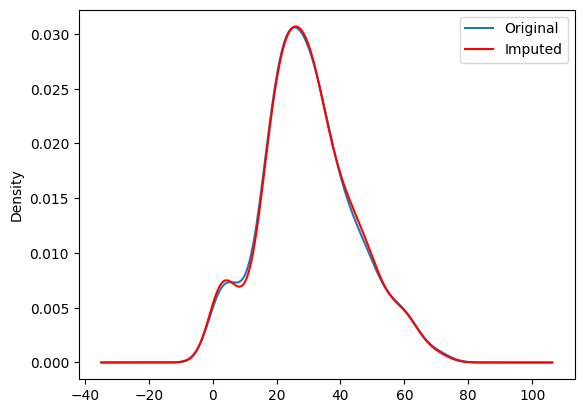

In [90]:
# distplot doesnt work
X_train['Age'].plot(kind = 'kde', label = 'Original')
X_train['Age_imputed'].plot(kind = 'kde', label = 'Imputed', color = 'red')
plt.legend()
plt.show()

In [91]:
# check the variance shift
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  204.5189704672957


In [92]:
# Check the covariance matrix
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,48.851247
Age,71.512440,204.349513,204.349513
Age_imputed,48.851247,204.349513,204.518970


<Axes: >

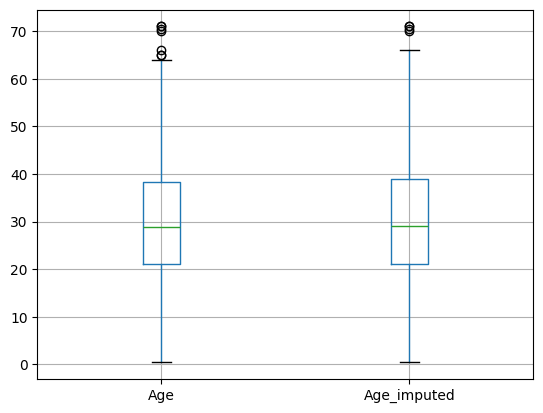

In [93]:
# check for outliers
X_train[['Age', 'Age_imputed']].boxplot()

In [94]:
# To keep random values same in all runs

# Extract the fare value safely
fare_val = X_train['Fare']

# Fallback to seed 42 if the fare is missing, infinite, or corrupt
if np.where(pd.isnull(fare_val)) or np.isinf(fare_val):
    current_seed = 42
else:
    current_seed = int(fare_val)

# Run the random sampling safely
sampled_value = X_train['Age'].dropna().sample(1, random_state=current_seed).values[0]

In [95]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])


In [96]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [97]:
data.isnull().mean() * 100


,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [98]:
X = data
y = data['SalePrice']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [99]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [100]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1452,NaN,TA,145000,TA,NaN
1104,NaN,TA,106000,TA,NaN
615,NaN,TA,137500,TA,NaN
928,TA,TA,236500,TA,TA
266,TA,TA,185000,TA,TA


In [101]:
null_indices_train_GarageQual_imputed = X_train['GarageQual_imputed'].isnull()
null_indices_test_GarageQual_imputed = X_test['GarageQual_imputed'].isnull()
null_indices_train_FireplaceQu_imputed = X_train['FireplaceQu_imputed'].isnull()
null_indices_test_FireplaceQu_imputed = X_test['FireplaceQu_imputed'].isnull()

X_train.loc[null_indices_train_GarageQual_imputed, 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test.loc[null_indices_test_GarageQual_imputed, 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train.loc[null_indices_train_FireplaceQu_imputed, 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test.loc[null_indices_test_FireplaceQu_imputed, 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

- This below code calculates and compares the distribution percentages of your categorical values before and after running your random sample imputation.-

- It checks whether your imputation strategy successfully preserved the original shape and balance of your dataset.

In [102]:

temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [103]:
temp

,original,imputed
TA,0.951043,0.953767
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [104]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.650954
TA,0.412439,0.539843
Fa,0.040917,0.053872
Po,0.027823,0.033670
Ex,0.024550,0.032548


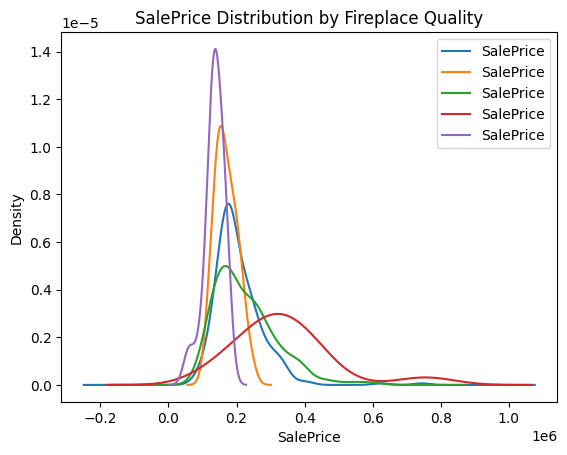

In [105]:
# distributions before imputation

for category in X_train['FireplaceQu'].dropna().unique():
    X_train[X_train['FireplaceQu'] == category]['SalePrice'].plot(kind = 'kde', xlabel = category)
plt.xlabel('SalePrice')
plt.title('SalePrice Distribution by Fireplace Quality')
plt.legend(title='Fireplace Quality')
plt.legend()
plt.show()

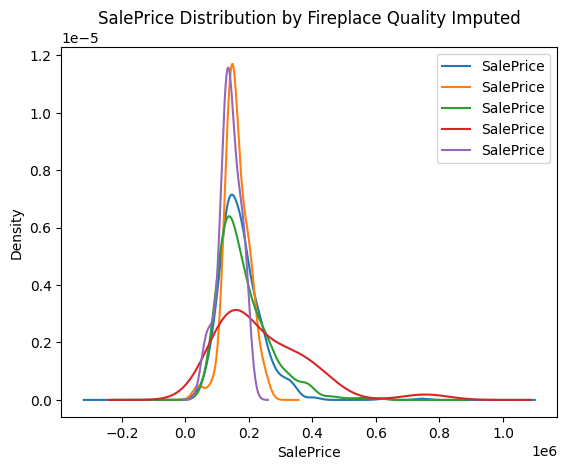

In [106]:
# distributions after imputation

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'].plot(kind = 'kde', xlabel = category)
plt.xlabel('SalePrice')
plt.title('SalePrice Distribution by Fireplace Quality Imputed')
plt.legend(title='Fireplace Quality Imputed')
plt.legend()
plt.show()